# JUNE 25th-anniversary analysis — Step 7: topics from our own list

**What this does:** counts JUNE articles by topic, using a list of topics we
wrote ourselves, each with a short definition and the words that signal it.
This is the hand-built alternative to the automatic topic groups in Step 4
(see OPEN_QUESTIONS.md): easier to explain, and each topic means what we say
it means.

- An article can have **several topics**.
- A topic counts if any of its words appear in the article's **title,
  keywords, or abstract**.
- Results are by **era** (groups of volumes), as in Step 4. Workshop
  articles are included.

A word search misses articles that use other words and catches some that use
the words in another sense, so every article's topics can be corrected by
hand in `hand_checks.csv` (see "Hand checks" below).

**What you need to do:**
1. Run each cell from top to bottom (under a minute).
2. Check the `topics` columns of `hand_checks.csv`: correct them where the suggestion is
   wrong, and mark rows `checked`. Run again to update the table and figure.
3. To change what a topic catches, edit its words in `TOPICS` in Settings.
   The `topics: matched words` column in `hand_checks.csv`, and the list printed
   under Part 1, show which words did the matching.

**What goes in:** `data/june_matched.csv` (from Step 2) and `hand_checks.csv`

**What comes out:** the `topics` suggestions in `hand_checks.csv`,
`figures/fig8_topics_by_era`, and `tables/table12_topics_by_era.csv`

## Running in Google Colab

If you opened this notebook from the "Open in Colab" link, run the next cell
first. It downloads the project's files from GitHub (the CSVs from earlier
steps and `manual_fixes.csv`) so the rest of the notebook can find them.
On your own computer, the cell does nothing.

**Colab forgets everything when the session ends.** To keep a result, download
it from the Files panel (folder icon on the left). Make hand corrections in
`hand_checks.csv` on GitHub, not in Colab, so they aren't lost.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("manual_fixes.csv"):
    if not os.path.exists("JUNE_Utilities"):
        subprocess.run(["git", "clone", "https://github.com/ajuavinett/JUNE_Utilities.git"], check=True)
    os.chdir("JUNE_Utilities")
    print("Working in", os.getcwd())

## Settings — the only cell you should normally need to edit

In [2]:
MATCHED_CSV = "data/june_matched.csv"
# The hand-check file, shared with Step 6: one row per article (see "Hand checks" below)
HAND_CHECKS_CSV = "hand_checks.csv"

# Which kinds of items to include (same as Steps 4 and 6). Workshop articles are included.
ITEM_TYPES = ["article", "case study", "technical"]

# Eras, as ranges of volumes (same as Steps 4 and 6)
ERAS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 24)]

# Each topic: (definition, the words that signal it). The words are "regular expressions":
#   |   means "or"          \b  means a word boundary ("\bcures?\b" = "cure" or "cures", not "secure")
#   ?   means "optional"    (?:...) groups words     capitalization never matters
#   (?!...) means "not followed by" ("diversity(?! of neur)" skips "diversity of neurons")
# The topic names are what people type in the "topics" column of hand_checks.csv.
TOPICS = {
    "DEI": (
        "Diversity, equity, inclusion, access, or belonging, for students or faculty, "
        "including programs for underrepresented groups",
        r"(?<!cellular )(?<!neuronal )(?<!genetic )(?<!a )\bdiversity\b(?! of)|\bdiverse (?:students|learners|populations?|backgrounds?)|"
        r"\bequit(?:y|able)\b|inclusi(?:on|ve|vity)|\bdei\b|underrepresented|\burms?\b|minorit(?:y|ies)|"
        r"\bhbcus?\b|historically black|hispanic[- ]serving|first[- ]generation|belonging|accessibility|"
        r"disabilit|\bdisabled\b|\bracism|anti-?racis|\bracial|marginalized|\bgender\b|\bwomen in"),
    "Faculty professional development": (
        "Developing undergraduate neuroscience educators: workshops, FUN/SfN programs, faculty networks, "
        "careers at primarily undergraduate institutions",
        r"faculty development|professional development|faculty (?:workshops?|networks?|mentor|careers?)|"
        r"(?:early[- ]career|new|junior|pre-?tenure) faculty|\bpuis?\b|primarily undergraduate institution|"
        r"\btenure\b|teaching workshop|workshop for faculty"),
    "Active learning & teaching strategies": (
        "Classroom teaching methods, and comparisons of methods",
        r"active learning|flipped|team[- ]based learning|\bpogil\b|think[- ]pair[- ]share|\bgames?\b|gamif|"
        r"clickers?|collaborative learning|cooperative learning|peer instruction|inquiry[- ]based|"
        r"problem[- ]based learning|jigsaw|role[- ]play|course structure|critical thinking"),
    "Curriculum & program design": (
        "Designing courses, majors, programs, and learning goals",
        r"curriculum (?:design|development|reform|revision|mapping)|curricular (?:design|reform|change|development|innovation|best practices)|"
        r"(?:design|develop|revis|reform)\w* (?:of )?(?:the|a|an|our|their) (?:new )?(?:neuroscience |undergraduate )?curricul|"
        r"neuroscience (?:majors?|minors?|programs?|degrees?)|interdisciplinary|course design|"
        r"course development|learning objectives|learning outcomes|core competenc|blueprint|program design|syllabus"),
    "Assessment": (
        "Measuring what students learn or how they feel",
        r"assessment (?:of (?:student|learning)|tools?|methods?|strateg|instruments?)|assessing (?:student|learning)|"
        r"(?:formative|summative|program|outcomes?) assessment|learning gains|pre[- ]?(?:and|/) ?post|pre-? ?tests?|post-? ?tests?|concept inventory|"
        r"self-efficacy|student attitudes|attitudes (?:toward|about)|student surveys?|surveyed (?:students|participants)|rubric"),
    "Human cognitive & physiological labs": (
        "Labs that record from people, usually the students themselves",
        r"\beeg\b|electroencephalogra|\berps?\b|event[- ]related potential|\bemg\b|electromyogra|\becg\b|\bekg\b|"
        r"electrocardiogra|\bfmri\b|functional magnetic|eye[- ]tracking|reaction times?|cognitive neuroscience|"
        r"psychophysiolog|heart rate|galvanic skin|skin conductance"),
    "Open data & programming": (
        "Students write code or work with public datasets",
        r"python|matlab|programming|\bcoding\b|jupyter|rstudio|\br programming|arduino|raspberry pi|"
        r"open data|open[- ]access data|publicly available data|allen (?:brain|cell|institute)|database|"
        r"neuroinformatics|bioinformatics|big data|data science|neuromorpho|openneuro"),
    "Animal behavior": (
        "Labs where students measure what animals do",
        r"animal behavio|behavioral assay|etholog|open[- ]field|\bmazes?\b|conditioning|courtship|"
        r"aggressi(?:on|ve) behavio|locomot|feeding behavio|social behavio|anxiety[- ]like|place preference|operant|"
        r"(?:rats?|mouse|mice|fish|fly|flies|crickets?|insects?|crayfish|zebrafish|worms?|animals?|rodents?)(?:'s?)? behavio"),
    "Online & remote teaching": (
        "Teaching online, hybrid, or remotely, including the shift during the pandemic",
        r"\bonline (?:courses?|class|learning|instruction|teaching|labs?|format|delivery|environment|setting|sections?|modality|semester)|"
        r"remote (?:learning|teaching|instruction|labs?|format|delivery)|emergency remote|"
        r"virtual (?:labs?|courses?|class|learning|instruction|format|meeting|semester|teaching)|"
        r"distance (?:learning|education)|\bhybrid\b|pandemic|covid|asynchronous (?:online|courses?|lectures?|learning|format)|\bzoom\b"),
    "Graduate training & careers": (
        "Preparing for, or doing, graduate school, and careers after a neuroscience degree",
        r"\bgraduate (?:school|programs?|training|students?|education|admissions?|studies)|\bph\.? ?d\b|doctoral|"
        r"post-?bac|master'?s|admissions|teaching assistants?|postdoc|careers in|career (?:paths?|options|development|readiness|"
        r"preparation|exploration|planning|outcomes|trajectories)"),
    "Writing & primary literature": (
        "Teaching students to read, write, and communicate science",
        r"writing|primary literature|primary (?:research )?(?:articles|papers|sources)|journal club|"
        r"reading (?:scientific|primary|research)|scientific (?:papers|literature|articles)|"
        r"\bcreate (?:method|approach|strategy|pedagogy)|peer review|science communication|"
        r"scientific communication|communicat(?:e|ing) science|literature review"),
    "Modeling the nervous system": (
        "Simulations and computational models of neurons, circuits, or behavior",
        r"simulat|computational model|computer model|computational neuroscience|neurons in action|swimmy|"
        r"metaneuron|hodgkin|neural networks?|cartoon network|"
        r"models? (?:of|for) (?:the )?(?:neurons?|neural|nervous|networks?|circuits?|membranes?|action potentials?)"),
    "Outreach & community engagement": (
        "Students teaching or serving the public",
        r"outreach|community engagement|community[- ]engaged|service[- ]learning|\bk-?12\b|high school|middle school|"
        r"elementary|brain awareness|museum|general public|\bthe public\b|science fair|brain bee|community partners?"),
    "Electrophysiology labs": (
        "Recording electrical activity from nerves or neurons",
        r"electrophysiolog|action potentials?|extracellular|intracellular|suction electrode|spikerbox|backyard brains|"
        r"patch[- ]clamp|voltage[- ]clamp|current[- ]clamp|nerve recording|compound action|membrane potential|"
        r"sharp electrode|spike sort"),
    "Sensation & perception labs": (
        "Hands-on labs on the senses",
        r"\bsensory|sensation|psychophysic|\btastes?\b|gustat|olfact|\bsmell|miracle fruit|gymnema|illusion|"
        r"visual system|\bvision\b|auditory|\bhearing\b|somatosens|two[- ]point|\btouch\b|proprioce|"
        r"(?:visual|taste|pain|color|colour|depth|auditory|sensory|speech|motion) perception|perception of (?:taste|pain|colou?r|sound|depth|motion)"),
    "Case studies": (
        "Using clinical, patient, or research cases to teach",
        r"case stud|case[- ]based|clinical case|patient case|clinical vignette|case histor"),
    "CUREs & undergraduate research": (
        "Students doing real research, in a course or on their own",
        r"\bcures?\b(?! for)|course[- ]based (?:undergraduate )?research|undergraduate research|research experiences?|"
        r"independent research|independent study|authentic research|summer research|\breu\b|"
        r"(?:honors|senior) thes[ie]s|student research projects?"),
    "Genetic model organisms & modern tools": (
        "Labs with Drosophila, C. elegans, or zebrafish, often using genetic tools",
        r"drosophila|fruit fl(?:y|ies)|c\. ?elegans|caenorhabditis|zebrafish|danio|optogenetic|chemogenetic|"
        r"crispr|\brnai\b|transgenic|genetic(?:ally)? (?:tools|engineer|modif|manipul)|mutants?\b|knock-?outs?\b|"
        r"gal4|channelrhodopsin|\bgenetics\b"),
}

FIGURES_DIR = "figures"
TABLES_DIR = "tables"

## Setup (no need to edit below this line)

In [3]:
import re
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

articles = pd.read_csv(MATCHED_CSV, keep_default_na=False, dtype=str, encoding="utf-8-sig")
articles = articles[articles["item_type"].isin(ITEM_TYPES)].reset_index(drop=True)
articles["volume"] = articles["volume"].astype(int)
articles["year_label"] = articles["year_label"].astype(int)
# Text to search: title, keywords, and abstract
articles["text"] = (articles["title"] + " ; " + articles["keywords"] + " ; " + articles["abstract"]).str.lower()


def era_of(volume):
    for first, last in ERAS:
        if first <= volume <= last:
            years = articles.loc[articles["volume"].between(first, last), "year_label"]
            return f"Vol {first}–{last} ({years.min()}–{years.max()})"
    return ""


articles["era"] = articles["volume"].map(era_of)
ERA_ORDER = list(dict.fromkeys(articles.sort_values("volume")["era"]))
print(f"{len(articles)} items ({', '.join(ITEM_TYPES)}), volumes "
      f"{articles['volume'].min()}–{articles['volume'].max()}; "
      f"{(articles['abstract'] == '').sum()} have no abstract (title and keywords only)")

# Shared figure style (Arial, Okabe–Ito colors, font sizes): see june.mplstyle
plt.style.use("june.mplstyle")
TEXT, TEXT_2, SURFACE = "#0b0b0b", "#404040", "#ffffff"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGURES_DIR, f"{name}.{ext}"), metadata={"CreationDate": None} if ext == "pdf" else None)
    print(f"saved {FIGURES_DIR}/{name}.png and .pdf")


def save_table(df, name, index=False):
    df.to_csv(os.path.join(TABLES_DIR, f"{name}.csv"), index=index, encoding="utf-8-sig")
    print(f"saved {TABLES_DIR}/{name}.csv")

# ---- The hand-check file, shared by Steps 6 and 7: one row per article ----
# Each question has a "(suggested)" column, refreshed on every run, and a column
# people fill in only to correct the suggestion. People's columns are never changed.
HAND_CHECK_COLUMNS = [
    "item_id", "volume", "issue", "year", "title", "checked", "note",
    "organisms (suggested)", "organisms",
    "computational (suggested)", "computational",
    "CURE (suggested)", "CURE", "CURE themes (suggested)", "CURE themes",
    "topics (suggested)", "topics",
    "organisms: times named", "organisms: self-experiment evidence",
    "computational: in abstract only", "topics: matched words",
]


def read_hand_checks():
    if os.path.exists(HAND_CHECKS_CSV):
        return pd.read_csv(HAND_CHECKS_CSV, keep_default_na=False, dtype=str)
    return pd.DataFrame(columns=HAND_CHECK_COLUMNS)


def update_hand_checks(refreshed):
    """Write this notebook's suggestion columns (a table indexed by item_id) into HAND_CHECKS_CSV."""
    checks = read_hand_checks()
    new = articles.loc[~articles["item_id"].isin(checks["item_id"]), ["item_id"]]
    if len(new):
        checks = pd.concat([checks, new], ignore_index=True)
        print(f"Added {len(new)} new article(s) to {HAND_CHECKS_CSV}")
    by_id = articles.set_index("item_id")
    info = pd.DataFrame({"volume": by_id["volume"].astype(str), "issue": by_id["issue"],
                         "year": by_id["year_label"].astype(str), "title": by_id["title"]}).join(refreshed)
    for col in info.columns:
        checks[col] = checks["item_id"].map(info[col])
    for col in HAND_CHECK_COLUMNS:
        if col not in checks:
            checks[col] = ""
    checks = checks[HAND_CHECK_COLUMNS + [c for c in checks.columns if c not in HAND_CHECK_COLUMNS]].fillna("")
    checks.to_csv(HAND_CHECKS_CSV, index=False, encoding="utf-8-sig")
    return checks


def decided(checks, column, names):
    """For each article and name, whether it counts: what people wrote in `column`, or else the suggestion."""
    answer = checks[column].str.strip()
    final = answer.where(answer != "", checks[f"{column} (suggested)"]).set_axis(checks["item_id"])
    chosen = final.str.split(";").map(lambda ns: [n.strip() for n in ns if n.strip() and n.strip().lower() != "none"])
    unknown = sorted(set(chosen.explode().dropna()) - set(names))
    if unknown:
        print(f"  ⚠ Not a name from Settings in the {column!r} column of {HAND_CHECKS_CSV} "
              f"(check the spelling): {', '.join(unknown)}")
    return pd.DataFrame({n: articles["item_id"].map(chosen.map(lambda ns, n=n: n in ns)).fillna(False).astype(bool)
                         for n in names})


def checked_by_hand(checks):
    """Which articles (aligned with `articles`) a person has marked checked."""
    done = checks.loc[checks["checked"].str.strip().str.lower() == "yes", "item_id"]
    return articles["item_id"].isin(done)

508 items (article, case study, technical), volumes 1–24; 5 have no abstract (title and keywords only)


## Hand checks: `hand_checks.csv`

One file, shared with Step 6, where people check everything the word searches
suggest. It has **one row per article**, so you can scroll through and check
an article's organisms, computational labs, CURE status, and topics at once.

For each question there are two columns:
- `… (suggested)` — what the word search suggests. **Refreshed on every run**,
  so improving the word lists in Settings updates it.
- the answer column (`organisms`, `computational`, `CURE`, `CURE themes`,
  `topics`) — **leave it empty to accept the suggestion.** To correct it,
  write what's right, separated by "; " and spelled as in Settings, or
  `none` if nothing applies. Whatever is written here replaces the suggestion.

Plus, for the whole row:
- `checked` — write `yes` once a person has checked the row.
- `note` — anything worth remembering.

The last columns help decide: how many times each organism is named, the
phrase suggesting students are their own subjects, kinds of computational
lab named only in the abstract, and the words behind each topic.

Later runs never change `checked`, `note`, or the answer columns; new
articles are added at the bottom.

## Part 1: find each article's topics

The word search **suggests** topics for every article, into the `topics`
columns of `hand_checks.csv` (see "Hand checks" above). `topics: matched
words` shows the words behind each suggestion, and the list printed below
shows the words doing the most matching in each topic, to help tune the
word lists in Settings.

In [4]:
# Which words matched, for each topic and article
matches = pd.DataFrame({name: articles["text"].map(lambda t, w=words: sorted(set(m.group(0) for m in re.finditer(w, t))))
                        for name, (_, words) in TOPICS.items()})
suggested = matches.apply(lambda col: col.str.len() > 0)

# Suggestions into the hand-check file; the "topics" column decides
checks = update_hand_checks(pd.DataFrame({
    "topics (suggested)": suggested.apply(lambda r: "; ".join(r.index[r]), axis=1),
    "topics: matched words": matches.apply(
        lambda r: " | ".join(f"{name}: {', '.join(w)}" for name, w in r.items() if w), axis=1),
}).set_axis(articles["item_id"]))
has_topic = decided(checks, "topics", list(TOPICS))
checked = checked_by_hand(checks)
print(f"{has_topic.any(axis=1).sum()} of {len(articles)} articles have at least one topic "
      f"(median {int(has_topic.sum(axis=1).median())} topics per article); "
      f"{checked.sum()} of {len(articles)} checked by hand")

# The words doing the most matching in each topic, to help tune the word lists
print("\nArticles per topic, and the words that matched most often:")
for name in TOPICS:
    words = matches[name].explode().dropna().value_counts().head(6)
    print(f"  {name} ({has_topic[name].sum()}): " + ", ".join(f"{w} {n}" for w, n in words.items()))

468 of 508 articles have at least one topic (median 2 topics per article); 1 of 508 checked by hand

Articles per topic, and the words that matched most often:
  DEI (66): underrepresented 18, diversity 18, inclusive 13, minority 12, inclusion 12, belonging 10
  Faculty professional development (32): professional development 14, primarily undergraduate institution 9, pui 6, puis 6, junior faculty 4, new faculty 3
  Active learning & teaching strategies (112): active learning 54, critical thinking 33, inquiry-based 17, flipped 11, collaborative learning 9, game 7
  Curriculum & program design (129): interdisciplinary 42, neuroscience programs 23, learning outcomes 19, neuroscience program 16, learning objectives 14, neuroscience majors 14
  Assessment (48): attitudes toward 9, post-test 7, learning gains 7, rubric 5, self-efficacy 5, pre/post 5
  Human cognitive & physiological labs (41): eeg 14, cognitive neuroscience 14, electroencephalogra 13, fmri 9, functional magnetic 6, event-rel

## Part 2: topics by era

For each topic, the percentage of each era's articles that have it. An
article with several topics counts once in each. Saved as
`tables/table12_topics_by_era.csv` (with each topic's definition and
article count) and `figures/fig8_topics_by_era`.

saved tables/table12_topics_by_era.csv


saved figures/fig8_topics_by_era.png and .pdf


,definition,articles,Vol 1–5 (2002–2007),Vol 6–10 (2007–2012),Vol 11–15 (2012–2017),Vol 16–20 (2017–2022),Vol 21–24 (2022–2026),all eras
topic,,,,,,,,
Curriculum & program design,"Designing courses, majors, programs, and learn...",129,24.0,27.4,23.5,26.3,25.6,25.4
Active learning & teaching strategies,"Classroom teaching methods, and comparisons of...",112,16.0,14.3,21.3,24.3,30.2,22.0
Writing & primary literature,"Teaching students to read, write, and communic...",85,24.0,9.5,20.6,17.1,12.8,16.7
Sensation & perception labs,Hands-on labs on the senses,73,8.0,20.2,18.4,11.8,10.5,14.4
CUREs & undergraduate research,"Students doing real research, in a course or o...",72,10.0,10.7,11.0,16.4,20.9,14.2
DEI,"Diversity, equity, inclusion, access, or belon...",66,10.0,9.5,6.6,15.1,24.4,13.0
Electrophysiology labs,Recording electrical activity from nerves or n...,63,18.0,9.5,12.5,13.2,10.5,12.4
Open data & programming,Students write code or work with public datasets,62,8.0,8.3,9.6,15.8,16.3,12.2
Graduate training & careers,"Preparing for, or doing, graduate school, and ...",54,8.0,11.9,8.8,10.5,14.0,10.6


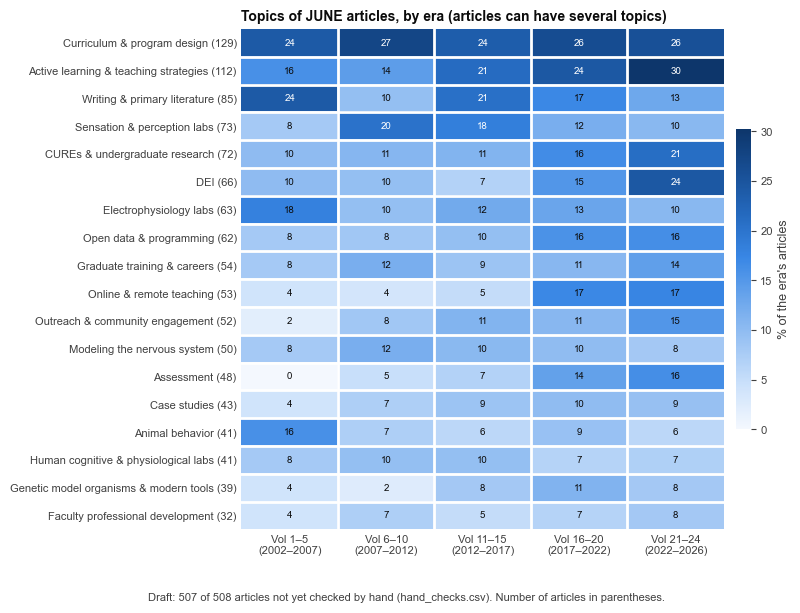

In [5]:
share = pd.DataFrame({era: has_topic[articles["era"] == era].mean() * 100 for era in ERA_ORDER})
share["all eras"] = has_topic.mean() * 100
share = share.sort_values("all eras", ascending=False)

table12 = share.round(1)
table12.insert(0, "articles", has_topic.sum()[share.index])
table12.insert(0, "definition", [TOPICS[n][0] for n in share.index])
table12.index.name = "topic"
save_table(table12, "table12_topics_by_era", index=True)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
data = share[ERA_ORDER]
im = ax.imshow(data.values, cmap=BLUES, aspect="auto", vmin=0)
for (y, x), v in pd.DataFrame(data.values).stack().items():
    ax.text(x, y, f"{v:.0f}", ha="center", va="center", fontsize=7,
            color=SURFACE if v > 0.6 * data.values.max() else TEXT)
ax.set_xticks(range(len(ERA_ORDER)), [e.replace(" (", "\n(") for e in ERA_ORDER])
ax.set_yticks(range(len(data)), [f"{n} ({has_topic[n].sum()})" for n in data.index])
ax.tick_params(length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([x - 0.5 for x in range(1, len(ERA_ORDER))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(data))], minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
bar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
bar.set_label("% of the era's articles", color=TEXT_2)
bar.outline.set_visible(False)
ax.set_title("Topics of JUNE articles, by era (articles can have several topics)")
if (~checked).any():
    fig.text(0, 0, f"Draft: {(~checked).sum()} of {len(articles)} articles not yet checked by hand "
             f"({HAND_CHECKS_CSV}). Number of articles in parentheses.", color=TEXT_2, fontsize=8)
save(fig, "fig8_topics_by_era")
table12